In [1]:
from datascience import *
%matplotlib inline
path_data = '../../../assets/data/'
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=DeprecationWarning)

# Lecture 21

## Discussion Question: Super Soda

Manufacturers of Super Soda ran a taste test. 91 out of 200 tasters prefer Super Soda over its rival.
    
***QUESTION: Do fewer people prefer Super Soda than its rival, or is this just chance?***

* Null hypothesis: Equal proportions of the population prefer Super Soda and the Rival.
* Alternative hypothesis: Fewer people in the population prefer Super Soda.
* Test statistic: Observed number of people who prefer Super Soda.
* p-value: Probability of getting 91 or fewer people.

Create a function that randomly chooses between Super Soda, "S", and its Rival, "R". Then counts how many choose "S" out of particular sample size.

In [3]:
def simulate_one_count(sample_size):
    return np.count_nonzero(np.random.choice(['S', 'R'], sample_size) == 'S')


In [4]:
# COMPLETE: Use the function to generate one simulation with a sample size of 200.
simulate_one_count(200)

101

In [5]:
# Run that simulation 10000 times.
num_simulations = 10000
counts = make_array()
for i in np.arange(num_simulations):
    counts = np.append(counts, simulate_one_count(200))

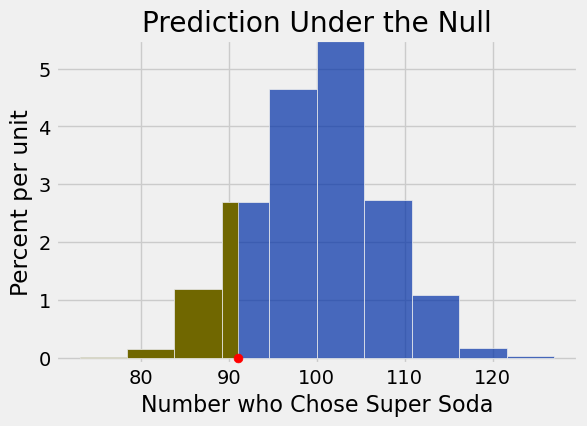

In [6]:
# Create a histogram of the results of all the simulations ran above. 

trials = Table().with_column('Number who Chose Super Soda', counts)
trials.hist(right_end=91)
plots.ylim(-0.001, 0.055)
plots.scatter(91, 0, color='red', s=40, zorder=3)
plots.title('Prediction Under the Null');

In [7]:
# Find the probability that 91 people would choose Super Soda.

np.count_nonzero(counts <= 91)/len(counts)

0.1158

***QUESTION: Based on the observed statistic and the value above (which has a name), how would you state your conclusion?***
    
Conclusion: 

## Changing the number of simulations

In [9]:
# Keeping the data fixed, we can re-run the test with a new simulation under the null
def run_test(num_simulations, sample_size):
    counts = make_array()
    for i in np.arange(num_simulations):
        counts = np.append(counts, simulate_one_count(sample_size))
    return counts

counts = run_test(10000, 200)

# Rerun the p-value.
np.count_nonzero(counts <= 91)/len(counts)

0.1197

In [10]:
# Let's repeat that 50 times for each number of simulations
tests = Table(['simulations', 'p-value for 91'])
for num_sims in [100, 1000, 10000]:
    for k in np.arange(50):
        counts = run_test(num_sims, 200)
        tests = tests.with_row([
            num_sims, 
            np.count_nonzero(counts <= 91)/len(counts),
        ])
tests.show(3)

simulations,p-value for 91
100,0.08
100,0.13
100,0.06


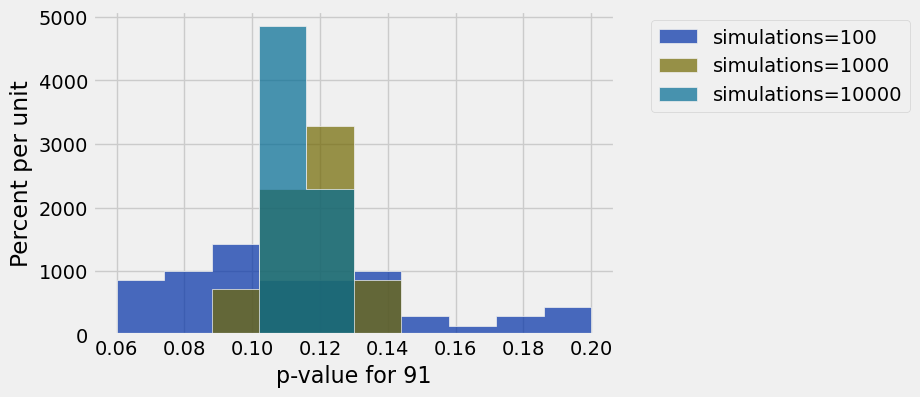

In [11]:
# For larger numbers of simulations, p-values are more consistent
tests.hist(1, group='simulations')

***QUESTION: What does this histogram show?***

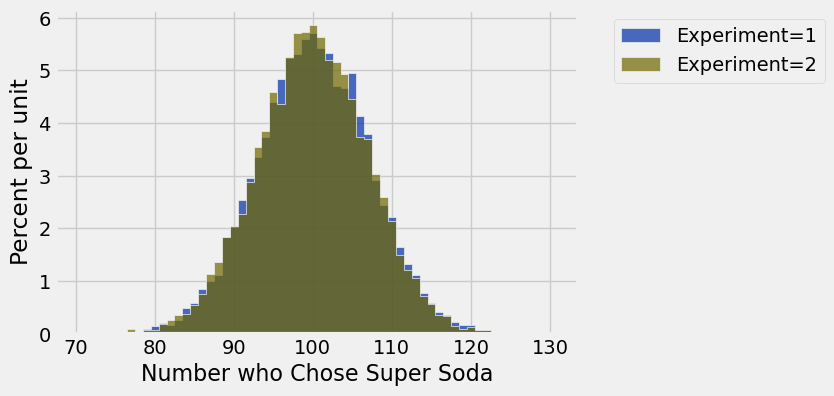

In [12]:
# A large number of simulations provides a good estimate of the
# theoretical distribution of the test statistic under the null hypothesis
num_sims = 10000
counts_1 = run_test(num_sims, 200)
counts_2 = run_test(num_sims, 200)
t = Table().with_columns(
    'Experiment', [1] * num_sims + [2] * num_sims,
    'Number who Chose Super Soda', np.append(counts_1, counts_2))
t.hist(1, group='Experiment', bins=np.arange(70.5, 131, 1))

## Running the Test Based on a Model.

Using the same hypotheses: 
* Null hypothesis: Equal proportions of the population prefer Super Soda and the Rival.
* Alternative hypothesis: Fewer people in the population prefer Super Soda.

In [13]:
# Suppose that the true proportion of people who prefer Super Soda is 45%
true_proportion = 0.45
true_distribution = make_array(true_proportion, 1 - true_proportion)
true_distribution

array([ 0.45,  0.55])

In [14]:
# Taste tests with 200 people will give varioius numbers of people who prefer Super Soda
sample_size = 200
sample_proportions(sample_size, true_distribution) * sample_size

array([  96.,  104.])

***QUESTION: If you ran only one sample and got your results, what might you conclude?***

In [19]:
# Create a function to run the sampling many times and return the p-value.

def run_experiment(num_simulations, sample_size, true_proportion):
    # Collect data based on the supposed true proportion.
    true_distribution = make_array(true_proportion, 1 - true_proportion)
    taste_test_results = sample_proportions(sample_size, true_distribution) * sample_size
    observed_stat_from_this_sample = taste_test_results.item(0)
    
    # Conduct hypothesis test
    counts = run_test(num_simulations, sample_size)
    p_value = np.count_nonzero(counts <= observed_stat_from_this_sample) / len(counts)
    return p_value



In [20]:
# COMPLETE: Run 10000 simulations, for a taste test of 200 people, with the assumed true proportion. 

run_experiment(10000, 200, 0.45)

0.36670000000000003

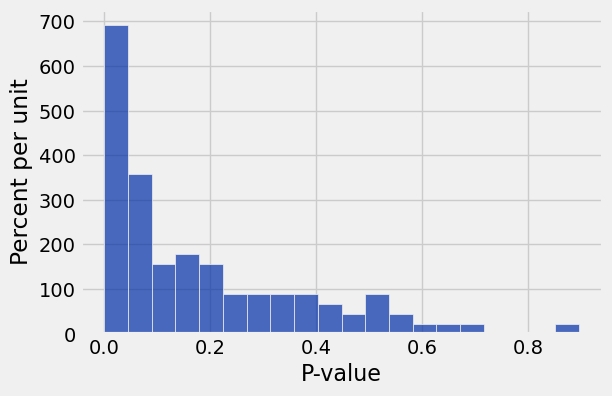

In [21]:
# Let's imagine running our taste test over and over again to see how often we reject the null
true_proportion = 0.45
sample_size = 200
p_values = make_array()
for k in np.arange(100):
    p_value = run_experiment(1000, sample_size, true_proportion)
    p_values = np.append(p_values, p_value)
Table().with_column('P-value', p_values).hist(0, bins=20)

***QUESTION: Based on a p-value cutoff of 5%,how often would you reject the null?***

## Discussion Question: American Roulette

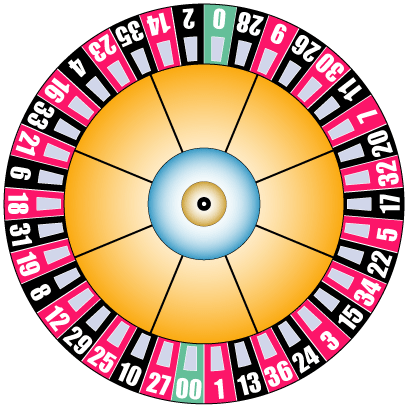

Suppose gamblers observed that red came up 166 times, black came up 186 times, and green came up 28 times in 380 plays.
     
***QUESTION: What are the expected values of a fair wheel played 380 times?***

***QUESTION: Does this seem to be a fair wheel?***

* Null hypothesis: The wheel is fair.
* Alternative hypothesis: The wheel is not fair.
* Test statistic: Observed Total Variance Distance (TVD).
* p-value: Probability of getting the observed distribution. 


In [22]:
# COMPLETE: Create an array of the fair distribution in the order red, black, green

wheel = make_array(18/38, 18/38, 2/38)

In [24]:
# COMPLETE: Create an array of the observed counts in the order red, black, green
obs_counts = make_array(166, 186, 28)

# COMPLETE: Calculate the proportion for each observed count.
obs_distribution = obs_counts / 380

# Calculate the TVD over the comparison. 
obs_tvd = sum(abs(obs_distribution - wheel))/2
obs_tvd

0.036842105263157891

In [26]:
# Create a function that runs what we did above. 
def simulate_one_tvd():
    sample_dist = sample_proportions(380, wheel)
    return sum(abs(sample_dist - wheel))/2

In [27]:
# Run 10000 simulations. 

num_simulations = 10000
tvds = make_array()
for i in np.arange(10000):
    tvds = np.append(tvds, simulate_one_tvd())

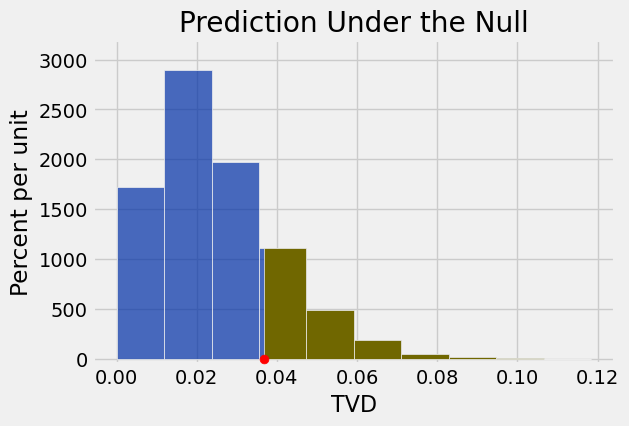

In [28]:
# Show the data in a histogram. 

Table().with_column('TVD', tvds).hist(left_end=obs_tvd)

# Plots the observed value 
plots.ylim(-0.5, 32)
plots.scatter(obs_tvd, 0, color='red', s=40, zorder=3)
plots.title('Prediction Under the Null');

***QUESTION: What value does the code below calculate?***

In [29]:
np.count_nonzero(tvds >= obs_tvd)/num_simulations

0.20760000000000001

***QUESTION: Based on the observed statistic and the value above (which has a name), how would you state your conclusion?***
    
Conclusion: 